In [1]:
import pandas as pd

In [2]:
# Load dataset
data = pd.read_csv('synthetic_indian_upi_fraud_data.csv')

In [3]:
# Display basic information about the dataset
print("Dataset Info:")
print(data.info())
print("\nSample Data:")
print(data.head())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionID         10000 non-null  int64  
 1   UserID                10000 non-null  object 
 2   Amount                10000 non-null  float64
 3   Timestamp             10000 non-null  object 
 4   MerchantCategory      10000 non-null  object 
 5   TransactionType       10000 non-null  object 
 6   DeviceID              10000 non-null  object 
 7   IPAddress             10000 non-null  object 
 8   Latitude              10000 non-null  float64
 9   Longitude             10000 non-null  float64
 10  AvgTransactionAmount  10000 non-null  float64
 11  TransactionFrequency  10000 non-null  object 
 12  UnusualLocation       10000 non-null  bool   
 13  UnusualAmount         10000 non-null  bool   
 14  NewDevice             10000 non-null  bool   
 15  Failed

In [4]:
data.head()

,TransactionID,UserID,Amount,Timestamp,MerchantCategory,TransactionType,DeviceID,IPAddress,Latitude,Longitude,AvgTransactionAmount,TransactionFrequency,UnusualLocation,UnusualAmount,NewDevice,FailedAttempts,FraudFlag,PhoneNumber,BankName
0,842835309389,b0b99baa-1fd2-41e5-ac94-37aa0ec862f9,8589.00,2024-01-22 03:59:58,Electronics,P2M,42296fa1-8d7a-478c-a8c9-590b9d14cdb9,75.122.84.213,23.354478,-40.536076,670.31,5/day,False,True,False,2,True,2798604680,Bank of Baroda
1,592863054785,0cc467c5-8b71-4ba4-9c75-4a9e2bec2c8c,9090.54,2024-07-01 13:43:33,Electronics,P2M,e566b8a8-17c3-4372-9e07-e4c4eb3113b7,16.110.81.53,-62.956912,-102.511919,7265.96,3/day,False,True,False,2,False,3614149152,ICICI Bank
2,373481869464,f7de03ee-b7f5-4568-8ba2-e889bced4d88,8814.41,2024-04-02 05:23:39,Electronics,P2P,897d0824-bc4f-4ee7-9bfb-c8eea31b2ca2,6.47.215.37,-13.112830,-18.978059,8750.89,3/day,True,False,True,3,False,912661191911,ICICI Bank
3,285572156436,456b3f39-e9cc-429f-8568-125612c12987,3971.25,2024-06-14 16:13:43,Restaurants,P2P,a4d2f5ef-19c7-4baa-b3ea-b04069d65021,214.166.195.254,-23.898771,81.760634,8348.14,1/day,True,True,False,4,False,916358088125,State Bank of India
4,874207772966,7b4b734d-f0c5-4dce-8b9c-0b2e226abc86,4376.74,2024-07-16 03:22:40,Groceries,P2M,8aee664a-fb51-4e74-98a1-cf632a02cd27,151.99.121.13,11.383999,12.669192,1719.74,1/day,True,True,False,0,False,5132838721,ICICI Bank


In [5]:
import numpy as np
from sklearn.model_selection import train_test_split

In [6]:
# Handle missing values if any
data = data.dropna()

In [7]:
# Convert dates to datetime and extract features
if 'Timestamp' in data.columns:
    data['Timestamp'] = pd.to_datetime(data['Timestamp'])
    data['Year'] = data['Timestamp'].dt.year
    data['Month'] = data['Timestamp'].dt.month
    data['Day'] = data['Timestamp'].dt.day
    data['Hour'] = data['Timestamp'].dt.hour
    data = data.drop('Timestamp', axis=1)


In [8]:
categorical_cols = ['TransactionType', 'MerchantCategory', 'BankName']
data = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

flag_cols = ['UnusualLocation', 'UnusualAmount', 'NewDevice']
for col in flag_cols:
    data[col] = data[col].astype(int)

drop_cols = ['TransactionID', 'UserID', 'DeviceID', 'IPAddress', 'PhoneNumber']
data = data.drop(drop_cols, axis=1)

data = data.fillna(0)

In [9]:
# Feature selection and target variable
X = data.drop('FraudFlag', axis=1)
y = data['FraudFlag']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=0)

In [10]:
# Verify all features are numeric
print(X.dtypes)

Amount                            float64
Latitude                          float64
Longitude                         float64
AvgTransactionAmount              float64
TransactionFrequency               object
UnusualLocation                     int32
UnusualAmount                       int32
NewDevice                           int32
FailedAttempts                      int64
Year                                int32
Month                               int32
Day                                 int32
Hour                                int32
TransactionType_P2P                  bool
MerchantCategory_Electronics         bool
MerchantCategory_Entertainment       bool
MerchantCategory_Groceries           bool
MerchantCategory_Restaurants         bool
MerchantCategory_Travel              bool
MerchantCategory_Utilities           bool
BankName_Bank of Baroda              bool
BankName_HDFC Bank                   bool
BankName_ICICI Bank                  bool
BankName_Kotak Mahindra Bank      

In [11]:
X_train.shape

(8500, 25)

In [12]:
X_test.shape

(1500, 25)

In [13]:
fraud = np.count_nonzero(y_train == 1)

In [14]:
print('Fraud cases in training data', fraud) 

Fraud cases in training data 826


In [15]:
# Identify non-numeric columns
non_numeric_columns = X_train.select_dtypes(include=['object']).columns
print("Non-numeric columns:", non_numeric_columns)

Non-numeric columns: Index(['TransactionFrequency'], dtype='object')


In [16]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
scaler = StandardScaler()

In [17]:
# Encode or drop non-numeric columns
for col in non_numeric_columns:
    encoder = LabelEncoder()
    X_train[col] = encoder.fit_transform(X_train[col])
    X_test[col] = encoder.transform(X_test[col])

# Ensure all columns are numeric
print(X_train.dtypes)

Amount                            float64
Latitude                          float64
Longitude                         float64
AvgTransactionAmount              float64
TransactionFrequency                int32
UnusualLocation                     int32
UnusualAmount                       int32
NewDevice                           int32
FailedAttempts                      int64
Year                                int32
Month                               int32
Day                                 int32
Hour                                int32
TransactionType_P2P                  bool
MerchantCategory_Electronics         bool
MerchantCategory_Entertainment       bool
MerchantCategory_Groceries           bool
MerchantCategory_Restaurants         bool
MerchantCategory_Travel              bool
MerchantCategory_Utilities           bool
BankName_Bank of Baroda              bool
BankName_HDFC Bank                   bool
BankName_ICICI Bank                  bool
BankName_Kotak Mahindra Bank      

In [18]:
X_train =  scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
X_train[:5]

array([[ 1.0046839 ,  0.39021755,  1.50038869, -0.7059605 ,  0.00719737,
        -0.99741511, -0.99577364,  1.00235572, -0.01468593,  0.        ,
        -0.5036915 , -0.995965  ,  0.51339639,  1.00874411, -0.42047157,
        -0.40622891, -0.41112972,  2.45691348, -0.40838837, -0.40583575,
        -0.44898025, -0.43929769, -0.45614994, -0.45426668,  2.26068833],
       [-0.04634365, -1.28741219,  1.04345443, -1.1256542 ,  0.00719737,
        -0.99741511,  1.0042443 , -0.99764982,  0.69057065,  0.        ,
        -0.00434723, -1.11021971, -1.52205823, -0.99133169, -0.42047157,
        -0.40622891, -0.41112972, -0.40701474,  2.44864958, -0.40583575,
        -0.44898025, -0.43929769, -0.45614994,  2.20135009, -0.44234315],
       [-1.43619884,  1.08540784,  1.16984116,  0.66682987,  0.00719737,
        -0.99741511,  1.0042443 ,  1.00235572, -0.01468593,  0.        ,
        -0.5036915 , -0.42469147, -0.64972053, -0.99133169,  2.37828205,
        -0.40622891, -0.41112972, -0.40701474, -0

In [20]:
X_test[:5]

array([[-0.25080651, -0.28726662, -1.08301511, -1.00272842, -1.21635628,
        -0.99741511, -0.99577364,  1.00235572,  1.39582722,  0.        ,
         0.9943413 ,  1.40338384, -1.23127899,  1.00874411, -0.42047157,
        -0.40622891,  2.43232235, -0.40701474, -0.40838837, -0.40583575,
         2.22726947, -0.43929769, -0.45614994, -0.45426668, -0.44234315],
       [ 0.88569153, -1.49301944, -1.55625828,  0.64076744,  1.23075103,
         1.00259159, -0.99577364,  1.00235572, -0.71994251,  0.        ,
         0.49499703,  1.06061972,  1.67651331,  1.00874411, -0.42047157,
        -0.40622891, -0.41112972, -0.40701474, -0.40838837, -0.40583575,
        -0.44898025,  2.27636073, -0.45614994, -0.45426668, -0.44234315],
       [-0.24321738, -0.87851313,  0.2040201 , -0.69488267, -1.21635628,
         1.00259159, -0.99577364,  1.00235572, -0.01468593,  0.        ,
        -0.5036915 ,  1.06061972, -1.66744784,  1.00874411, -0.42047157,
        -0.40622891, -0.41112972, -0.40701474, -0

NAIVE BAYES (NB)

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score

In [23]:
# Create and train the Naive Bayes model
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

GaussianNB()

In [24]:
# Make predictions
y_pred = nb_model.predict(X_test)

In [25]:
# Calculate the accuracy
acc_nb = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc_nb:.2f}")

Accuracy: 0.91


In [26]:
# Generate the classification report
report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

       False       0.91      1.00      0.95      1361
        True       0.00      0.00      0.00       139

    accuracy                           0.91      1500
   macro avg       0.45      0.50      0.48      1500
weighted avg       0.82      0.91      0.86      1500



C:\Users\Tanmay Chauhan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Tanmay Chauhan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Tanmay Chauhan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


DECISION TREE (DT)

In [28]:
from sklearn.tree import DecisionTreeClassifier

In [29]:
## Postpruning
treemodel=DecisionTreeClassifier()

In [30]:
treemodel.fit(X_train,y_train)

DecisionTreeClassifier()

In [31]:
import matplotlib.pyplot as plt
%matplotlib inline

[Text(0.7574916950820366, 0.9871794871794872, 'x[15] <= 1.028\ngini = 0.175\nsamples = 8500\nvalue = [7674, 826]'),
 Text(0.548789059145908, 0.9615384615384616, 'x[3] <= 0.924\ngini = 0.182\nsamples = 7296\nvalue = [6559, 737]'),
 Text(0.6531403771139723, 0.9743589743589745, 'True  '),
 Text(0.38216491801704894, 0.9358974358974359, 'x[2] <= 1.425\ngini = 0.174\nsamples = 5630\nvalue = [5089, 541]'),
 Text(0.16751255622948785, 0.9102564102564102, 'x[1] <= -1.718\ngini = 0.168\nsamples = 5138\nvalue = [4661, 477]'),
 Text(0.023670050373988703, 0.8846153846153846, 'x[12] <= -0.141\ngini = 0.444\nsamples = 12\nvalue = [8, 4]'),
 Text(0.022448862769042895, 0.8589743589743589, 'gini = 0.0\nsamples = 7\nvalue = [7, 0]'),
 Text(0.024891237978934513, 0.8589743589743589, 'x[1] <= -1.726\ngini = 0.32\nsamples = 5\nvalue = [1, 4]'),
 Text(0.023670050373988703, 0.8333333333333334, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.026112425583880324, 0.8333333333333334, 'gini = 0.0\nsamples = 4\nv

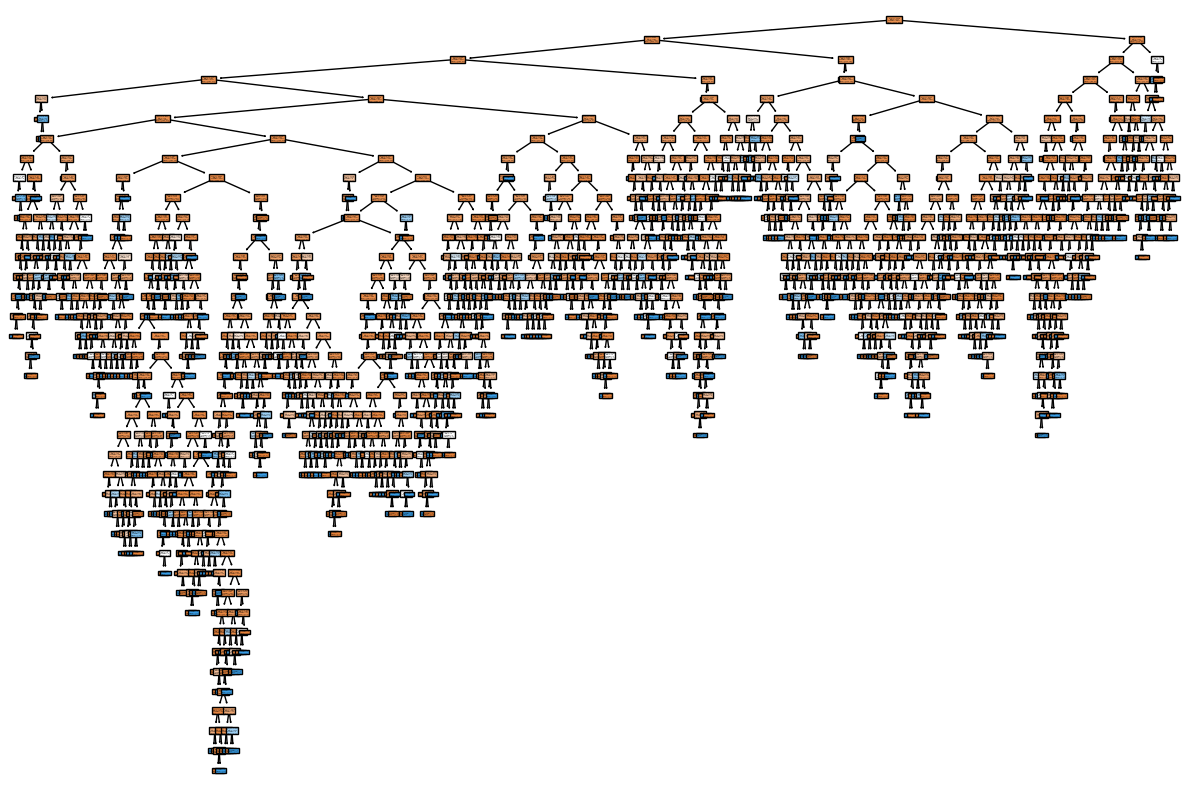

In [32]:
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(treemodel,filled=True)

In [33]:
y_pred=treemodel.predict(X_test)

In [34]:
y_pred

array([False, False, False, ..., False, False, False])

In [35]:
from sklearn.metrics import accuracy_score,classification_report

In [36]:
acc_dt=accuracy_score(y_pred,y_test)
print(acc_dt)

0.8133333333333334


In [37]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

       False       0.88      0.91      0.90      1325
        True       0.12      0.10      0.11       175

    accuracy                           0.81      1500
   macro avg       0.50      0.50      0.50      1500
weighted avg       0.80      0.81      0.80      1500



RANDOM FOREST (RF)

In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [40]:
rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [41]:
# Make predictions
y_pred = rf.predict(X_test)

In [42]:
# Calculate the accuracy
acc_rf = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc_rf:.2f}")

Accuracy: 0.91


In [43]:
# Generate the classification report
report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

       False       0.91      1.00      0.95      1361
        True       0.00      0.00      0.00       139

    accuracy                           0.91      1500
   macro avg       0.45      0.50      0.48      1500
weighted avg       0.82      0.91      0.86      1500



C:\Users\Tanmay Chauhan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Tanmay Chauhan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Tanmay Chauhan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


LOGISTIC REGRESSION

In [45]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression()

In [46]:
from sklearn.model_selection import GridSearchCV
parameter = {'penalty': ['l2', 'none'],  # Penalties compatible with 'lbfgs'
    'solver': ['lbfgs'],
    'C': [0.01, 0.1, 1, 10],
    'max_iter': [100, 200, 300]}

In [47]:
classifier_regressor = GridSearchCV(classifier, param_grid=parameter, scoring='accuracy', cv=5)

In [48]:
classifier_regressor.fit(X_train, y_train)

C:\Users\Tanmay Chauhan\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
60 fits failed out of a total of 120.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
60 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Tanmay Chauhan\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Tanmay Chauhan\anaconda3\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
  File "C:\Users\Tanmay Chauhan\anaconda3\Lib\site-packages\sklearn\base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "C:\Use

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [0.01, 0.1, 1, 10], 'max_iter': [100, 200, 300],
                         'penalty': ['l2', 'none'], 'solver': ['lbfgs']},
             scoring='accuracy')

In [49]:
print(classifier_regressor.best_params_)

{'C': 0.01, 'max_iter': 100, 'penalty': 'l2', 'solver': 'lbfgs'}


In [50]:
print(classifier_regressor.best_score_)

0.9028235294117646


In [51]:
#prediction
y_pred = classifier_regressor.predict(X_test)

In [52]:
#accuracy score
from sklearn.metrics import classification_report, accuracy_score

In [53]:
acc_lr = accuracy_score(y_pred,y_test)
print(acc_lr)

0.9073333333333333


In [105]:
scores = [acc_nb * 100,
          acc_dt * 100,
          acc_rf * 100,
          acc_lr * 100]

In [107]:
names = ["Naive Bayes",
         "Decision Tree",
         "Random Forest",
         "Logistic Regression"]

In [109]:
df = pd.DataFrame()
df['Algorithm Name'] = names
df['Accuracy Score (%)'] = scores
df = df.sort_values('Accuracy Score (%)', ascending = False)

In [111]:
df

,Algorithm Name,Accuracy Score (%)
0,Naive Bayes,90.733333
2,Random Forest,90.733333
3,Logistic Regression,90.733333
1,Decision Tree,81.333333


In [115]:
import matplotlib.pyplot as plt

In [121]:
import seaborn as sns

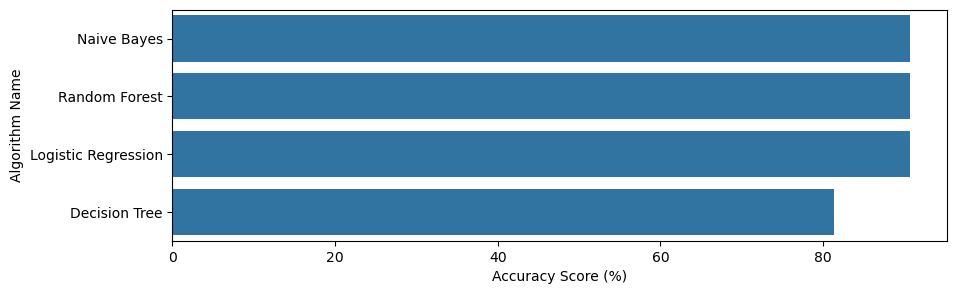

In [127]:
# Create a figure with a specific size
fig = plt.figure(figsize=(10, 3))

# Add a subplot (axes) to the figure
ax = fig.add_subplot(111)

# Use seaborn to create the barplot on the specified axes
sns.barplot(x="Accuracy Score (%)", y="Algorithm Name", data=df, ax=ax)

# Show the plot
plt.show()

In [129]:
import os.path